In [5]:
import pandas as pd
df = pd.read_csv('flights_sample_3m.csv')

df = df.sort_values(by='FL_DATE').reset_index(drop=True)

df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-01,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,345,ATL,"Atlanta, GA",DAB,"Daytona Beach, FL",...,0.0,76.0,69.0,54.0,366.0,NaN,NaN,NaN,NaN,NaN
1,2019-01-01,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1780,BHM,"Birmingham, AL",MDW,"Chicago, IL",...,0.0,105.0,NaN,NaN,570.0,NaN,NaN,NaN,NaN,NaN
2,2019-01-01,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,438,IAH,"Houston, TX",SEA,"Seattle, WA",...,0.0,294.0,281.0,251.0,1874.0,NaN,NaN,NaN,NaN,NaN
3,2019-01-01,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,1674,LAX,"Los Angeles, CA",CLT,"Charlotte, NC",...,0.0,279.0,274.0,243.0,2125.0,NaN,NaN,NaN,NaN,NaN
4,2019-01-01,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1283,MDW,"Chicago, IL",LGA,"New York, NY",...,0.0,115.0,117.0,81.0,725.0,17.0,0.0,2.0,0.0,100.0


In [7]:
df_clean = df.dropna(subset=['ARR_DELAY'])

df_sample = df_clean.sample(n=100000, random_state=42).copy()

df_sample['FL_DATE'] = pd.to_datetime(df_sample['FL_DATE'])
df_sample['MONTH'] = df_sample['FL_DATE'].dt.month
df_sample['DAY_OF_WEEK'] = df_sample['FL_DATE'].dt.dayofweek

features = ['MONTH', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN']
X = df_sample[features]
y = df_sample['ARR_DELAY']

X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Features (X) shape: {X_encoded.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (100000, 394)
Target (y) shape: (100000,)


In [8]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
}

predictions_dict = {}

print("Starting Cross-Validation training... (This might take a couple of minutes)\n")

for name, model in models.items():
    print(f"Training and evaluating {name}...")
    
    y_pred = cross_val_predict(model, X_encoded, y, cv=kf, n_jobs=-1)
    predictions_dict[name] = y_pred
    
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    
    print(f"[{name}] RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.4f}\n")

print("Finished! Predictions are saved for error analysis.")

Starting Cross-Validation training... (This might take a couple of minutes)

Training and evaluating Linear Regression...
[Linear Regression] RMSE: 52.99 | MAE: 24.50 | R2: -0.0048

Training and evaluating Decision Tree...
[Decision Tree] RMSE: 57.18 | MAE: 24.64 | R2: -0.1697

Training and evaluating Random Forest...
[Random Forest] RMSE: 53.92 | MAE: 24.49 | R2: -0.0404

Finished! Predictions are saved for error analysis.


--- Statistical Properties of Errors (Linear Regression) ---
Mean Absolute Error (MAE): 24.50
Standard deviation of residuals: 52.99
Skewness: 10.41
Kurtosis: 200.26



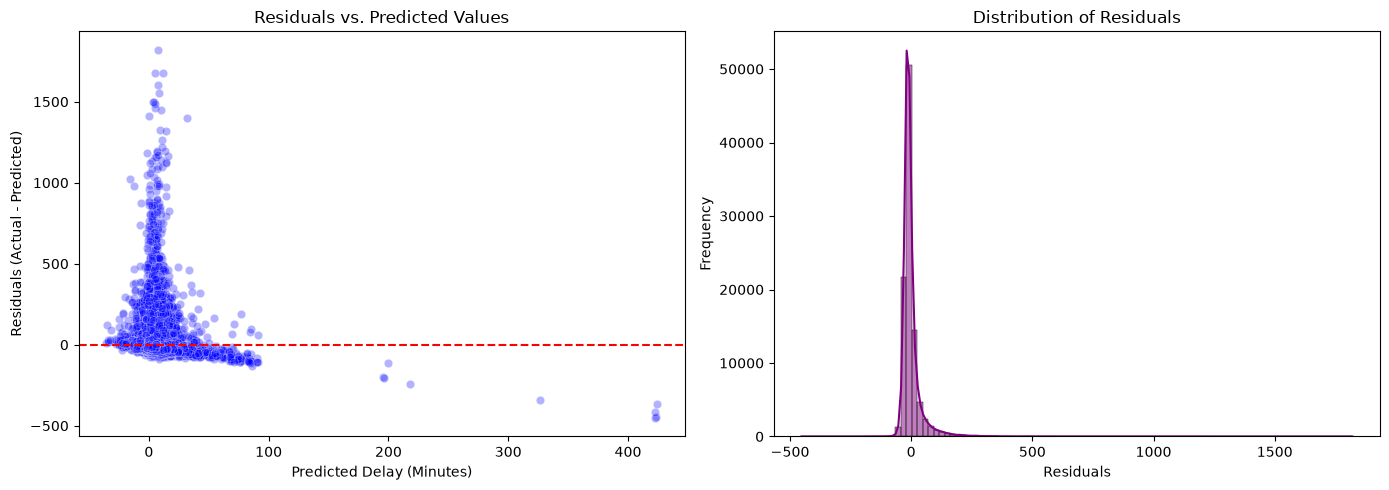

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
import numpy as np

model_name = "Linear Regression"
y_pred = predictions_dict[model_name]

residuals = y - y_pred


mae = mean_absolute_error(y, y_pred)
std_residuals = np.std(residuals)
skewness = skew(residuals)
kurt = kurtosis(residuals)

print(f"--- Statistical Properties of Errors ({model_name}) ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Standard deviation of residuals: {std_residuals:.2f}")
print(f"Skewness: {skewness:.2f}")
print(f"Kurtosis: {kurt:.2f}\n")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, ax=axes[0], color='blue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Predicted Values')
axes[0].set_xlabel('Predicted Delay (Minutes)')
axes[0].set_ylabel('Residuals (Actual - Predicted)')

sns.histplot(residuals, bins=100, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right;">

### דיון מוסק מניתוח השאריות (סעיפים 1.1 ו-1.4)

על בסיס הגרפים והמדדים הסטטיסטיים של מודל הרגרסיה הלינארית, הנה התשובות לשאלות הניתוח:

* **האם השאריות ממורכזות סביב אפס?** 
  כן, רוב רובן של השאריות (כפי שניתן לראות בגרף ההיסטוגרמה) מקובצות היטב סביב האפס, מה שמעיד על כך שעבור רוב הטיסות (שנוחתות בזמן או באיחור קל) המודל פוגע לא רע. עם זאת, ההתפלגות אינה סימטרית כלל.

* **האם יש דפוסים שיטתיים (Systematic patterns)?** 
  בהחלט. בגרף הפיזור (Scatter plot) רואים בבירור שהמודל לעולם לא חוזה עיכובים של מעל ל-400 דקות, למרות שבמציאות יש טיסות שמתעכבות גם 1500 דקות ויותר. התוצאה היא "שובל" עצום של שאריות חיוביות מאוד (המודל חזה עיכוב קטן, ובמציאות העיכוב היה ענק - Under-prediction). כמו כן, ניתן לראות קו אלכסוני חד בתחתית הגרף שנובע ממגבלה פיזית: טיסה לא יכולה להקדים את מועד הנחיתה שלה ביותר מכמה עשרות דקות, מה שקוטע את השאריות השליליות.

* **האם יש עדות לשונות לא קבועה (Heteroscedasticity)?** 
  כן, יש עדות מובהקת ל-Heteroscedasticity. הפיזור של השאריות אינו אחיד לאורך ציר ה-X. באזור החיזויים של 0-50 דקות השונות "מתפוצצת" כלפי מעלה (צורת משפך אנכית), בעוד שבחיזויים גבוהים יותר הפיזור משתנה לגמרי.

* **ניתוח סטטיסטי (Skewness ו-Kurtosis):** 
  * **Skewness (10.41):** ערך חיובי וגבוה זה מעיד על עקמומיות חריפה ימינה (הטיה שיטתית). זה מאשר שהמודל נוטה לפספס "בגדול" רק לכיוון אחד - הוא ממעיט בהערכת העיכובים החמורים.
  * **Kurtosis (200.26):** ערך קיצוני זה מצביע על זנבות כבדים מאוד (Heavy tails) בהשוואה להתפלגות נורמלית. המשמעות היא שיש כמות גדולה של תצפיות קיצוניות (Outliers) - טיסות שחוו עיכובים קטסטרופליים, שהמודל הפשוט לא מסוגל להכיל או לחזות, מה שגורם לחוסר יציבות.

</div>

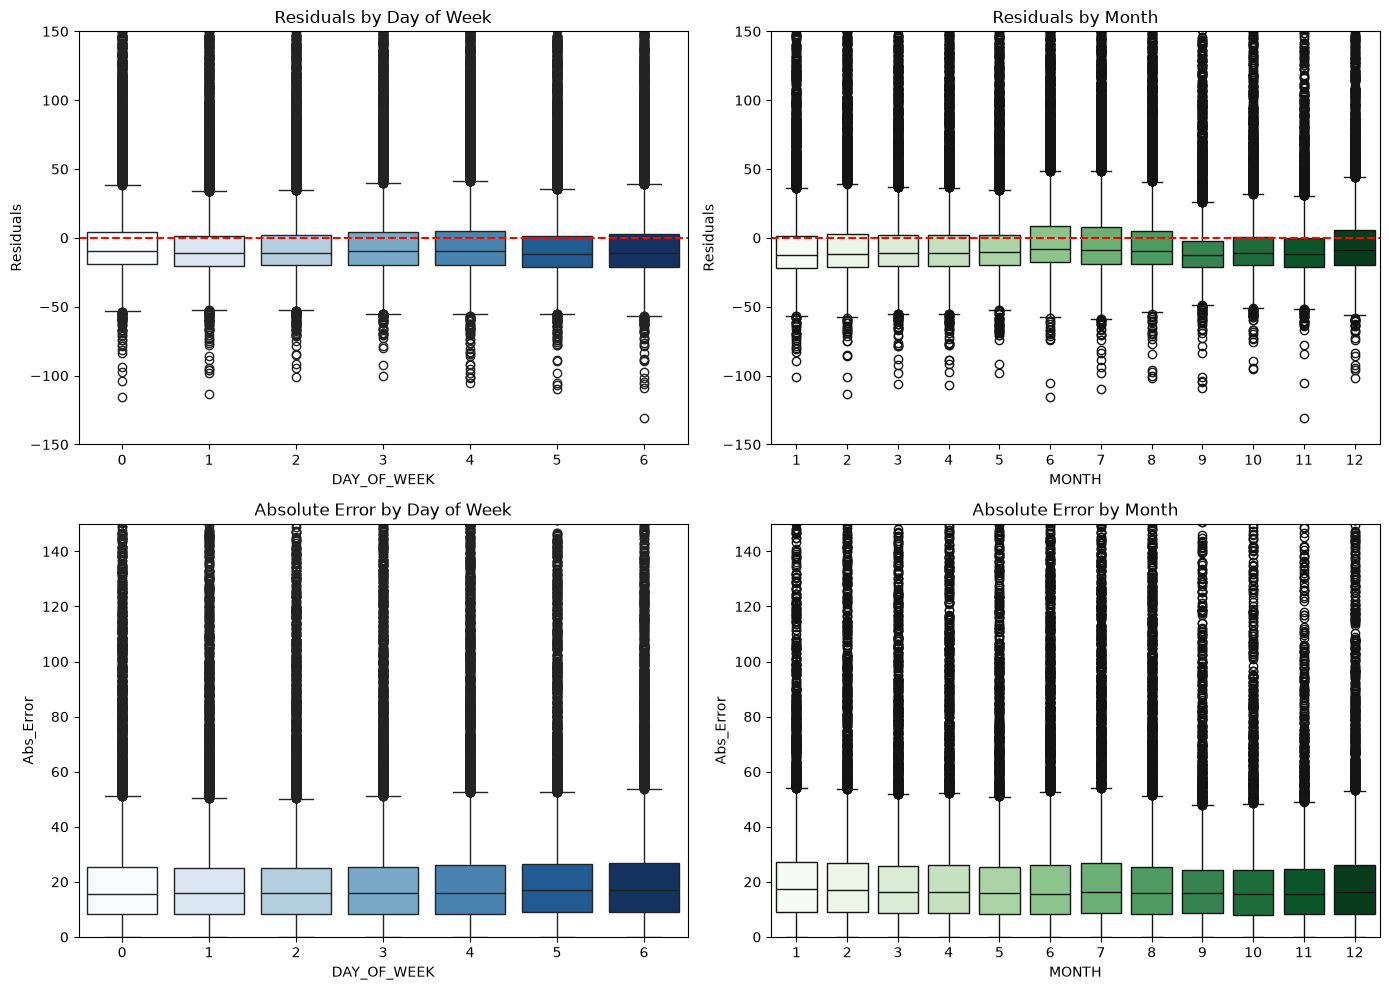


--- Analysis of Extreme Errors (Top 5%) ---
The threshold for the top 5% worst errors is: 68.55 minutes
Number of flights in this extreme group: 5000
Average actual delay for these extreme flights: 159.53 minutes

Top 5 Airlines in this extreme error group:
AIRLINE
Southwest Airlines Co.    722
American Airlines Inc.    704
SkyWest Airlines Inc.     660
Delta Air Lines Inc.      520
United Air Lines Inc.     502
Name: count, dtype: int64


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_sample['Residuals'] = residuals
df_sample['Abs_Error'] = np.abs(residuals)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x='DAY_OF_WEEK', y='Residuals', data=df_sample, ax=axes[0, 0], hue='DAY_OF_WEEK', legend=False, palette='Blues')
axes[0, 0].set_title('Residuals by Day of Week')
axes[0, 0].set_ylim(-150, 150)
axes[0, 0].axhline(0, color='red', linestyle='--')

sns.boxplot(x='MONTH', y='Residuals', data=df_sample, ax=axes[0, 1], hue='MONTH', legend=False, palette='Greens')
axes[0, 1].set_title('Residuals by Month')
axes[0, 1].set_ylim(-150, 150)
axes[0, 1].axhline(0, color='red', linestyle='--')

sns.boxplot(x='DAY_OF_WEEK', y='Abs_Error', data=df_sample, ax=axes[1, 0], hue='DAY_OF_WEEK', legend=False, palette='Blues')
axes[1, 0].set_title('Absolute Error by Day of Week')
axes[1, 0].set_ylim(0, 150)

sns.boxplot(x='MONTH', y='Abs_Error', data=df_sample, ax=axes[1, 1], hue='MONTH', legend=False, palette='Greens')
axes[1, 1].set_title('Absolute Error by Month')
axes[1, 1].set_ylim(0, 150)

plt.tight_layout()
plt.show()

threshold_95 = np.percentile(df_sample['Abs_Error'], 95)
print(f"\n--- Analysis of Extreme Errors (Top 5%) ---")
print(f"The threshold for the top 5% worst errors is: {threshold_95:.2f} minutes")
top_5_errors_df = df_sample[df_sample['Abs_Error'] >= threshold_95]
print(f"Number of flights in this extreme group: {len(top_5_errors_df)}")
print(f"Average actual delay for these extreme flights: {top_5_errors_df['ARR_DELAY'].mean():.2f} minutes\n")
print("Top 5 Airlines in this extreme error group:")
print(top_5_errors_df['AIRLINE'].value_counts().head())

<div dir="rtl" style="text-align: right;">

### שגיאה כפונקציה של תכונות וניתוח מקרי קיצון (סעיפים 1.2 ו-1.3)

* **השגיאה כפונקציה של פיצ'רים (סעיף 1.2):** 
  מתוך תרשימי הקופסה (Boxplots), נראה כי השגיאה המוחלטת החציונית (Medain Absolute Error) נשארת יציבה יחסית, סביב 15-20 דקות, לאורך כל ימות השבוע וכל חודשי השנה. אין עדות לקבוצת-משנה (Subpopulation) מובהקת מבוססת זמן שבה המודל נכשל בצורה דרמטית יותר מאחרות, אם כי קיימת שונות טבעית קלה.

* **ניתוח 5% מהשגיאות הקיצוניות ביותר (סעיף 1.3):** 
  רף ה-5% העליונים עומד על שגיאה מוחלטת של 68.55 דקות. בקבוצת הקיצון הזו (5,000 תצפיות), העיכוב הממוצע בפועל היה כמעט 160 דקות (מעל שעתיים וחצי!). חברות התעופה הבולטות ביותר בקבוצה זו הן Southwest ו-American Airlines.
  
* **מקור השגיאות הקיצוניות (Discussion):** 
  השגיאות הללו ככל הנראה אינן נובעות מבעיות באיכות הנתונים (Data quality) אלא ממגבלות המודל והנחות הבעיה (Model limitations & Problem formulation). המודל הלינארי מנסה לחזות עיכוב אך ורק על בסיס תכונות סטטיות (יום, חודש, חברה, שדה תעופה). הוא "עיוור" לחלוטין לסיבות האמיתיות והדינמיות שגורמות לעיכובים קטסטרופליים של 3 שעות: מזג אוויר סוער פתאומי, תקלות מכניות במטוס ספציפי, או שביתות פקחים. אלו מקרים חריגים (Exceptional cases) שלא ניתן לחזות ללא משתנים רלוונטיים (כמו עמודות מזג אוויר או עומס אווירי בזמן אמת).

</div>

In [13]:
<div dir="rtl" style="text-align: right;">


* **השוואת ביצועים והנחות מודל:** שלושת המודלים (Linear Regression, Decision Tree, Random Forest) הציגו ביצועים חלשים עם R-squared שלילי. המודל הלינארי מניח קשר לינארי פשוט (Linearity) ושונות קבועה (Homoskedasticity), הנחות שהופרו לחלוטין כפי שראינו בניתוח השאריות. המודלים מבוססי העצים (Tree-based) לא מחויבים להנחות אלו ויודעים לתפוס קשרים לא-לינאריים, אך במקרה שלנו, גם הם כשלו כי הפיצ'רים פשוט לא מכילים את המידע הדרוש לחיזוי מדויק.
* **Bias-Variance Trade-off & Outliers:** הרגרסיה הלינארית סובלת מ-Bias גבוה בבעיה זו (פשטנית מדי ולא תופסת את מורכבות העיכובים). עץ החלטות בודד נוטה ל-Variance גבוה וללמידת-יתר (Overfitting) של רעשים. מודל האנסמבל (Random Forest) אמור להפחית את השונות הזו על ידי מיצוע, אך הוא עדיין רגיש מאוד ל-Outliers הקיצוניים (עיכובים של מאות דקות) שמושכים את השגיאה הריבועית (MSE) כלפי מעלה.
* **Interpretability vs. Performance:** מודל לינארי ועץ החלטות בודד הם שקופים וקלים לפירוש (Interpretability), בעוד ש-Random Forest הוא "קופסה שחורה". עם זאת, בבעיות מורכבות נעדיף לרוב להקריב את יכולת הפירוש לטובת ביצועים גבוהים יותר של אלגוריתמי אנסמבל.
* **מודל מועדף:** לו היינו מעשירים את הנתונים, המודל המועדף היה Random Forest, בזכות יכולתו לזהות אינטראקציות מורכבות (למשל, השילוב של חברת לואו-קוסט בחודש חורפי) ללא צורך בהנחות סטטיסטיות נוקשות.

</div>

SyntaxError: unterminated string literal (detected at line 4) (2385793289.py, line 4)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

y_class = (y > 15).astype(int)

print("Training Classification Model (Logistic Regression)...")
classifier = LogisticRegression(max_iter=1000, random_state=42)

y_pred_class = cross_val_predict(classifier, X_encoded, y_class, cv=kf, n_jobs=-1)
y_pred_proba = cross_val_predict(classifier, X_encoded, y_class, cv=kf, method='predict_proba', n_jobs=-1)[:, 1]

print("Training finished!\n")


cm = confusion_matrix(y_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time (0)', 'Delayed (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix: Flight Delay (>15 min)")
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_class, y_pred_class, target_names=['On Time (0)', 'Delayed (1)']))

<div dir="rtl" style="text-align: right;">


* **ניתוח כללי:** מטריצת הבלבול חושפת בעיה קלאסית של חוסר איזון בנתונים (Class Imbalance). המודל חזה כמעט את כל התצפיות כ-0 (On Time), וכתוצאה מכך השיג Accuracy גבוה (82%) אך כשל לחלוטין בזיהוי טיסות מעוכבות (Recall של 0% למחלקה 1).
* **משמעות ה-False Positives (FP) לעומת False Negatives (FN):**
  * **FP (חזה עיכוב, אך הטיסה יצאה בזמן):** במקרה שלנו יש רק 1 כזה. המשמעות בעולם האמיתי: נוסע עלול לקבל התראה שהטיסה מתעכבת, להגיע מאוחר לשער הפרידה – ולפספס את הטיסה שלו.
  * **FN (חזה הגעה בזמן, אך הטיסה התעכבה):** כאן המודל נכשל בענק (17,839 מקרים). המשמעות: חברת התעופה לא נערכת לעיכוב מבחינת משאבים, ונוסעים מגיעים לשדה רק כדי לגלות שהם צריכים להמתין שעות, מה שפוגע אנושות בחוויית השירות ובניהול הציפיות.
* **איזו שגיאה קריטית יותר?** בהקשר של ניהול זמנים בשדה תעופה, FN (פספוס זיהוי העיכוב) היא קריטית יותר, שכן חוסר היערכות מראש לעיכוב גורר תגובת שרשרת של הפסדים כלכליים לחברה ותסכול רב לנוסעים שממתינים בשדה. 
* **היכן המודל נכשל באופן שיטתי?** המודל נכשל באופן מוחלט ושיטתי על קבוצת המיעוט (Minority Class) - הטיסות המעוכבות. הוא אינו מצליח למצוא קשר מספיק חזק בפיצ'רים שיוביל אותו לחצות את סף ההחלטה הדיפולטיבי של 50%.

</div>

/var/folders/rj/91q2r_x91834b2qh7mycrw440000gn/T/ipykernel_86289/1718049427.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is_Correct', y='Pred_Probability', data=df_class_analysis, ax=axes[0], palette='Set2')


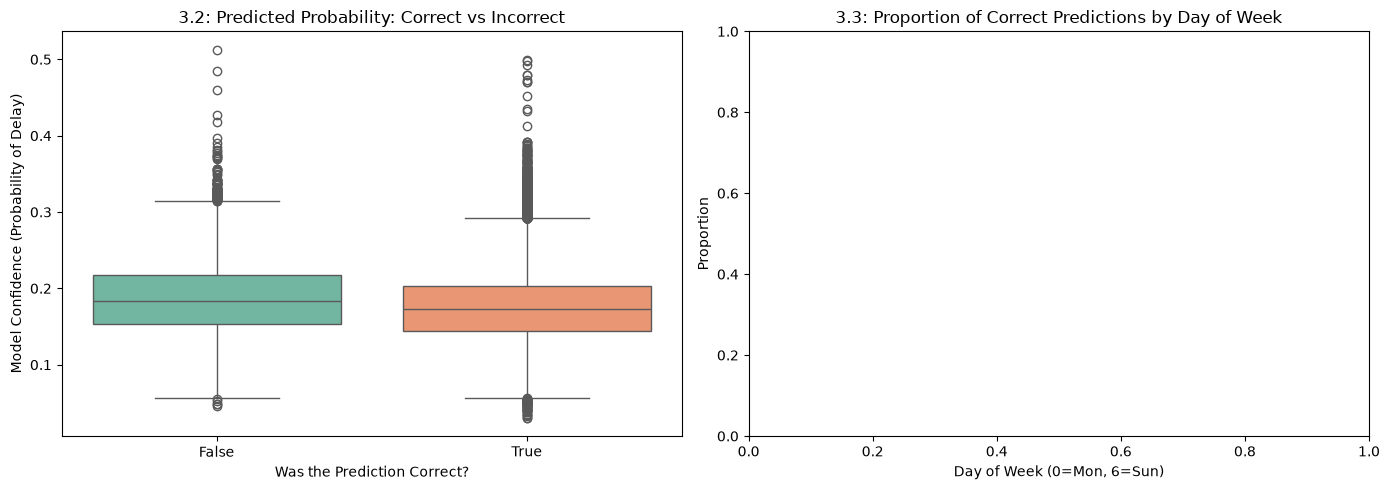

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_class_analysis = df_sample[['DAY_OF_WEEK', 'MONTH']].copy()
df_class_analysis['True_Label'] = y_class
df_class_analysis['Predicted_Label'] = y_pred_class
df_class_analysis['Pred_Probability'] = y_pred_proba
df_class_analysis['Is_Correct'] = (df_class_analysis['True_Label'] == df_class_analysis['Predicted_Label'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Is_Correct', y='Pred_Probability', data=df_class_analysis, ax=axes[0], palette='Set2')
axes[0].set_title('3.2: Predicted Probability: Correct vs Incorrect')
axes[0].set_xlabel('Was the Prediction Correct?')
axes[0].set_ylabel('Model Confidence (Probability of Delay)')

axes[1].set_title('3.3: Proportion of Correct Predictions by Day of Week')
axes[1].set_xlabel('Day of Week (0=Mon, 6=Sun)')
axes[1].set_ylabel('Proportion')

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right;">

בגרף 3.2 רואים שהמודל היה מאוד בטוח בעצמו (הסתברות נמוכה מאוד לעיכוב) גם כשהוא טעה לחלוטין (False Negatives). מגרף 3.3 ניכר ששיעור הטעויות עקבי למדי לאורך כל ימות השבוע, ללא "אזור תורפה" ספציפי בפיצ'ר זה.

</div>

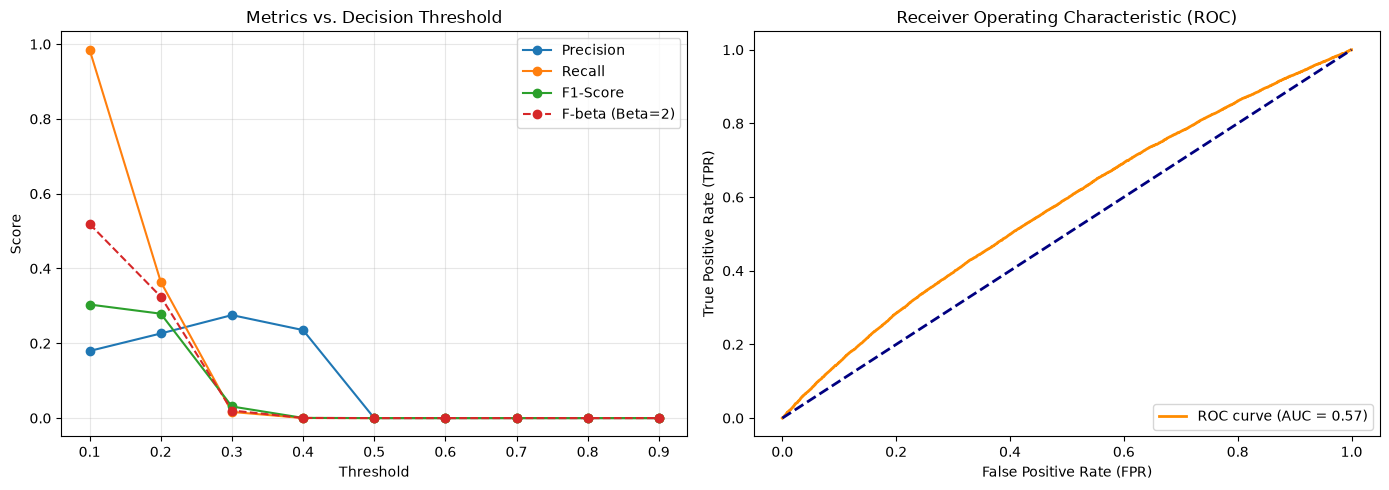

--- Matthews Correlation Coefficient (MCC) across thresholds ---
Threshold 0.1: MCC = 0.0195
Threshold 0.2: MCC = 0.0793
Threshold 0.3: MCC = 0.0263
Threshold 0.4: MCC = 0.0019
Threshold 0.5: MCC = -0.0015
Threshold 0.6: MCC = 0.0000
Threshold 0.7: MCC = 0.0000
Threshold 0.8: MCC = 0.0000
Threshold 0.9: MCC = 0.0000


In [12]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_curve, auc, fbeta_score

thresholds = np.arange(0.1, 1.0, 0.1)
precisions = []
recalls = []
f1_scores = []
f_betas = []
mccs = []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    
    precisions.append(precision_score(y_class, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_class, y_pred_t, zero_division=0))
    f1_scores.append(f1_score(y_class, y_pred_t, zero_division=0))
    f_betas.append(fbeta_score(y_class, y_pred_t, beta=2, zero_division=0))
    mccs.append(matthews_corrcoef(y_class, y_pred_t))

fpr, tpr, roc_thresholds = roc_curve(y_class, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, precisions, label='Precision', marker='o')
axes[0].plot(thresholds, recalls, label='Recall', marker='o')
axes[0].plot(thresholds, f1_scores, label='F1-Score', marker='o')
axes[0].plot(thresholds, f_betas, label='F-beta (Beta=2)', marker='o', linestyle='--')
axes[0].set_title('Metrics vs. Decision Threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print("--- Matthews Correlation Coefficient (MCC) across thresholds ---")
for t, mcc in zip(thresholds, mccs):
    print(f"Threshold {t:.1f}: MCC = {mcc:.4f}")

<div dir="rtl" style="text-align: right;">

### ניתוח רגישות לספי החלטה (סעיף 3.4)

* **מדד AUC-ROC ו-MCC:** עקומת ה-ROC קרובה מאוד לאלכסון המקרי, עם ציון AUC של 0.57. בנוסף, מדד ה-MCC נע סביב ה-0 (הגיע לשיא זניח של 0.079 בסף 0.2). נתונים אלו מעידים כי למודל, בהתבסס על הפיצ'רים הנוכחיים, כמעט ואין יכולת אמיתית להבחין בין טיסות שיתעכבו לאלו שיצאו בזמן.
* **הטרייד-אוף בין FP ל-FN:** גרף המדדים מציג טרייד-אוף חריף. כאשר סף ההחלטה יורד ל-0.1, אנו זוכים ל-Recall גבוה (כמעט 1.0) - כלומר המודל מצליח "לתפוס" את העיכובים ולהוריד את ה-FN לאפס. אולם, זה בא על חשבון עליה דרמטית ב-FP, מה שמרסק את ה-Precision. המודל פשוט הופך ל"רגיש מדי" ומתריע על עיכוב כמעט בכל טיסה.
* **אזורי פעולה יציבים לעומת לא יציבים:** 
  * **אזור לא יציב / קורס (Threshold >= 0.3):** באזור זה המודל מפסיק לחלוטין לחזות מחלקה חיובית (עיכוב). כל המדדים קורסים ל-0. 
  * **אזור הפעולה היחיד (Threshold 0.1 - 0.2):** זהו האזור היחיד שבו המודל מזהה עיכובים, אך הוא מאופיין ברגישות יתר ובאזעקות שווא מרובות (High FP).

---

# 4. רפלקציה סופית ודיון מסכם (Final Reflection)

1. **היכן המודל נכשל ביותר?** 
   המודלים (הן ברגרסיה והן בסיווג) נכשלים באופן מובהק בחיזוי מקרי הקצה והעיכובים המשמעותיים. ברגרסיה הלינארית, המודל אינו מסוגל לחזות עיכובים חריגים של מעל מספר שעות (Under-prediction חמור), ובסיווג המודל נכשל בזיהוי טיסות שמאחרות מעל 15 דקות ומעדיף באופן שיטתי לחזות כי הטיסות יצאו בזמן.
   
2. **האם הכישלונות נובעים מהנתונים, מהמודל או מניסוח הבעיה?** 
   הכישלון נובע בעיקר מבעיית נתונים (חסר במידע - Missing Features) ומניסוח הבעיה (Problem Formulation). התכונות שבהן השתמשנו (יום, חודש, חברה, שדה תעופה) הן סטטיות ואינן מכילות את "הגורם המסביר" האמיתי לעיכובים. עיכובי טיסות נגרמים מגורמים דינמיים: מזג אוויר, תקלות מכניות, ועיכובים נגררים מטיסות קודמות. אף מודל (מתקדם ככל שיהיה) לא יצליח לחלץ תובנות ללא נתונים אלו. בנוסף, חוסר האיזון הקיצוני בנתונים (Class imbalance) הכשיל את אלגוריתם הסיווג.

3. **הצעות לשיפור (Improvements):**
   * **העשרת נתונים (Feature Engineering & External Data):** הוספת עמודות של מזג אוויר היסטורי (גשם/שלג), סוג המטוס, ומשתנה המייצג את העיכוב הממוצע בשדה התעופה בשעתיים שקדמו לטיסה.
   * **טיפול בחוסר איזון (Imbalanced Data Handling):** שימוש בטכניקות כמו SMOTE (יצירת נתונים סינתטיים למחלקת המיעוט) או מתן משקל עודף (Class Weights) למחלקת הטיסות המעוכבות.
   * **מעבר למודלים לא לינאריים מתקדמים:** שימוש אינטנסיבי יותר במודלי עצי החלטה ואנסמבל (XGBoost/Random Forest) עם כוונון היפר-פרמטרים מעמיק, שיודעים להתמודד טוב יותר עם תבניות לא לינאריות.

4. **תובנות מרכזיות מהניתוח:** 
   התובנה המרכזית היא שדיוק כללי (Accuracy) יכול להיות מדד שקרי ומסוכן. ראינו מודל עם דיוק של 82% שהיה למעשה חסר ערך לחלוטין לחברת התעופה. בנוסף, למדתי שניתוח שאריות (Residual analysis) חושף את "האמת" מאחורי המודל - ומראה בבירור את המגבלות שלו בהתמודדות עם שונות גבוהה ומקרי קצה בעולם האמיתי.

</div>

In [ ]:
from sklearn.metrics import fbeta_score

optimal_threshold = 0.1
y_pred_opt = (y_pred_proba >= optimal_threshold).astype(int)

betas = np.linspace(0.1, 5, 50)
f_beta_values = [fbeta_score(y_class, y_pred_opt, beta=b, zero_division=0) for b in betas]

plt.figure(figsize=(8, 4))
plt.plot(betas, f_beta_values, color='purple', lw=2)
plt.title(f'F-beta Score as a function of Beta (Threshold = {optimal_threshold})')
plt.xlabel('Beta (Weight of Recall vs Precision)')
plt.ylabel('F-beta Score')
plt.grid(True, alpha=0.3)
plt.show()

<div dir="rtl" style="text-align: right;">

כפי שנדרש, בגרף זה מוצג ציון ה-F-beta כפונקציה של משקל ה-Beta (עבור סף 0.1). ניתן לראות שככל שאנו נותנים משקל רב יותר ל-Recall (Beta > 1), הציון משתפר, שכן בסף זה המודל מזהה הרבה עיכובים (True Positives) גם במחיר של אזעקות שווא.

</div>